## FashionMNIST 분류 모델

In [56]:
# torchvision은 PyTorch의 컴퓨터 비전 전용 라이브러리임

import torchvision

from torch.utils.data import Dataset, DataLoader

# transforms: 이미지 전처리와 데이터 증강을 위한 변환 함수들을 모음
import torchvision.transforms as transforms
# - 이미지 크기 조정, 정규화, 회전, 자르기 등의 기능을 제공함
# - 훈련 전에 이미지 데이터를 모델이 처리하기 좋은 형태로 변환함
# - 데이터 증강으로 훈련 데이터의 다양성을 늘려서 성능을 향상시킴
# - transforms라는 별명으로 줄여서 사용하여 코드를 간결하게 만듦

# datasets: 유명한 컴퓨터 비전 데이터셋들을 쉽게 사용할 수 있게 해주는 모듈임
from torchvision import datasets
# - CIFAR-10, MNIST, ImageNet 등의 표준 데이터셋을 자동으로 다운로드하고 로드함
# - 이미 전처리가 완료된 상태로 제공되어서 바로 사용 가능함
# - 연구나 학습용으로 널리 사용되는 벤치마크 데이터셋들을 포함함


# 데이터 처리 및 시각화 라이브러리들을 가져옴
import numpy as np                                  # 수치 계산과 배열 처리를 위한 라이브러리
import matplotlib.pyplot as plt                     # 그래프와 차트를 그리기 위한 시각화 라이브러리
plt.style.use('seaborn-v0_8-white')                     # 그래프 스타일을 깔끔한 seaborn-white 테마로 설정함

GPU 설정

In [58]:
# PyTorch에서 GPU/CPU 디바이스를 자동으로 선택하는 코드

# torch.cuda.is_available(): CUDA(GPU)가 사용 가능한지 확인하는 함수
# - True: GPU 사용 가능 → 'cuda' 선택
# - False: GPU 사용 불가 → 'cpu' 선택
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# device 변수에는 현재 시스템에서 최적의 연산 장치가 저장됨
# - GPU가 있으면: device = torch.device('cuda')
# - GPU가 없으면: device = torch.device('cpu')
print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cpu


### 데이터 로드

In [59]:
# 이미지 데이터 전처리를 위한 변환 파이프라인 정의

# transforms.Compose(): 여러 개의 변환을 순차적으로 적용하는 컨테이너
# 리스트 안의 변환들이 위에서부터 차례대로 실행됨
transform = transforms.Compose([
    # transforms.ToTensor(): PIL 이미지나 numpy 배열을 PyTorch 텐서로 변환
    # - 픽셀 값 범위를 [0, 255]에서 [0.0, 1.0]으로 자동 정규화
    # - 차원 순서를 (H, W, C)에서 (C, H, W)로 변경 (PyTorch 표준)
    transforms.ToTensor(),
    
    # transforms.Normalize(): 텐서의 각 채널을 평균과 표준편차로 정규화
    # 첫 번째 튜플 (0.5, ): 각 채널의 평균값 (RGB 3채널이므로 0.5, 0.5, 0.5의 축약)
    # 두 번째 튜플 (0.5, ): 각 채널의 표준편차 (RGB 3채널이므로 0.5, 0.5, 0.5의 축약)
    # 공식: (pixel - mean) / std
    # 결과: [0, 1] 범위가 [-1, 1] 범위로 변환됨
    transforms.Normalize((0.5, ), (0.5, ))
])

In [60]:
# Fashion-MNIST 데이터셋을 훈련용과 테스트용으로 분리하여 로드

# 훈련용 데이터셋 생성
trainset = datasets.FashionMNIST(
    root='/data/',           # 데이터를 저장할 루트 디렉토리 경로
    train=True,                 # True: 훈련용 데이터 (60,000개 샘플)
    download=True,              # True: 데이터가 없으면 자동 다운로드
    transform=transform         # 앞서 정의한 전처리 변환 파이프라인 적용
)

# 테스트용 데이터셋 생성
testset = datasets.FashionMNIST(
    root='/content/',           # 동일한 루트 디렉토리 사용 (중복 다운로드 방지)
    train=False,                # False: 테스트용 데이터 (10,000개 샘플)
    download=True,              # True: 데이터가 없으면 자동 다운로드
    transform=transform         # 동일한 전처리 변환 적용 (일관성 유지)
)

In [62]:
# 데이터셋을 배치 단위로 효율적으로 로드하는 DataLoader 생성

# 훈련용 데이터 로더
train_loader = DataLoader(
    trainset,               # 앞서 생성한 훈련용 데이터셋
    batch_size=128,         # 한 번에 처리할 샘플 개수 (128개씩 묶어서 처리)
    shuffle=True,           # 매 에포크마다 데이터 순서를 섞음 (과적합 방지)
    num_workers=2           # 데이터 로딩을 위한 병렬 프로세스 개수
)

# 테스트용 데이터 로더  
test_loader = DataLoader(
    testset,                # 앞서 생성한 테스트용 데이터셋
    batch_size=128,         # 훈련과 동일한 배치 크기 사용 (일관성)
    shuffle=False,          # 평가 시에는 순서를 섞지 않음 (재현 가능한 결과)
    num_workers=2           # 동일한 병렬 처리 설정
)

In [63]:
# DataLoader에서 첫 번째 배치를 가져와서 데이터 구조 확인

# next(iter(train_loader)): train_loader에서 첫 번째 배치 하나만 가져옴
# - iter(): DataLoader를 이터레이터로 변환
# - next(): 이터레이터에서 다음 요소(첫 번째 배치) 반환
# 반환값: (images, labels) 튜플 형태
images, labels = next(iter(train_loader))

# 가져온 데이터의 형태(shape) 확인
# images.shape: 이미지 배치의 차원 정보 출력
# - 예상 결과: torch.Size([128, 1, 28, 28])
# - 해석: [배치크기, 채널수, 높이, 너비]
print(f"이미지 배치 형태: {images.shape}")

# labels.shape: 라벨 배치의 차원 정보 출력  
# - 예상 결과: torch.Size([128])
# - 해석: [배치크기] (각 이미지마다 하나의 클래스 라벨)
print(f"라벨 배치 형태: {labels.shape}")

이미지 배치 형태: torch.Size([128, 1, 28, 28])
라벨 배치 형태: torch.Size([128])


In [64]:
# Fashion-MNIST 데이터셋의 숫자 라벨을 실제 의류 이름으로 매핑하는 딕셔너리

labels_map = {
    0: 'T-Shirt',       # 티셔츠 - 상의 카테고리
    1: 'Trouser',       # 바지 - 하의 카테고리  
    2: 'Pullover',      # 풀오버(스웨터) - 상의 카테고리
    3: 'Dress',         # 드레스 - 원피스 카테고리
    4: 'Coat',          # 코트 - 아우터 카테고리
    5: 'Sandal',        # 샌들 - 신발 카테고리
    6: 'Shirt',         # 셔츠 - 상의 카테고리
    7: 'Sneaker',       # 스니커즈 - 신발 카테고리
    8: 'Bag',           # 가방 - 액세서리 카테고리
    9: 'Ankle Boot',    # 앵클부츠 - 신발 카테고리
}

# 사용 예시:
# 모델이 예측한 숫자(0~9)를 실제 의류명으로 변환
# predicted_class = 3
# item_name = labels_map[predicted_class]  # 'Dress'

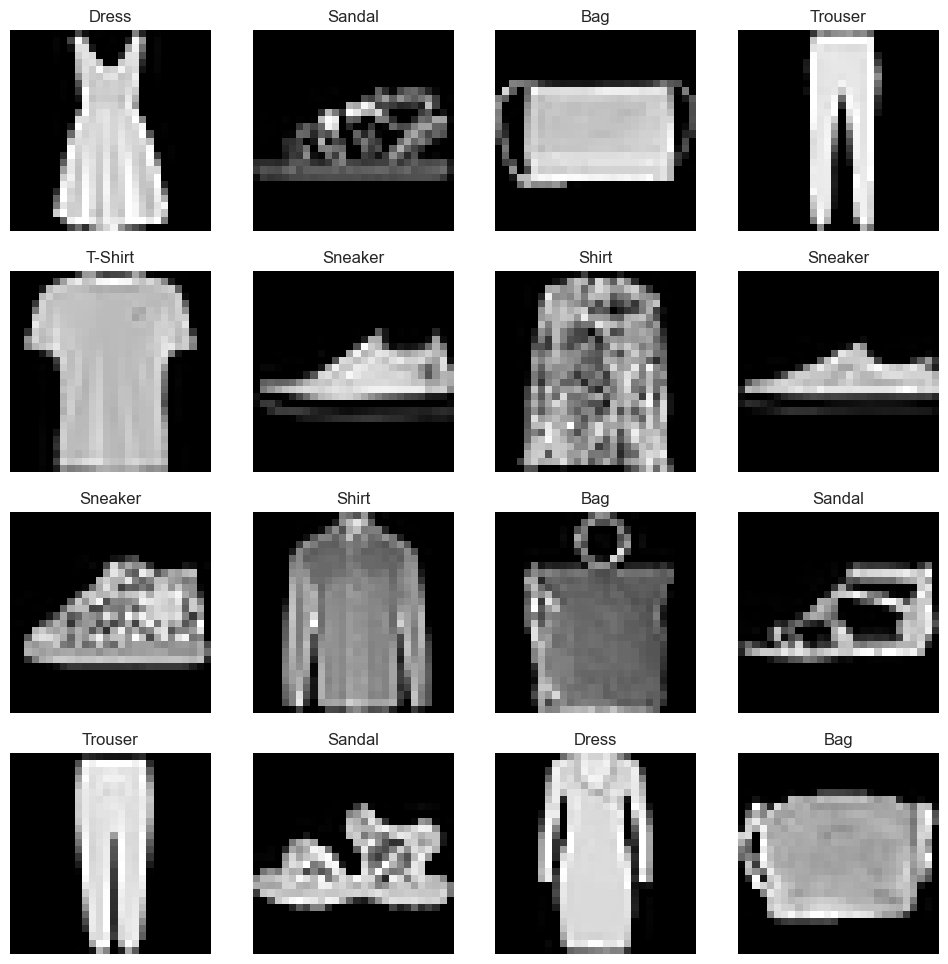

In [65]:
# Fashion-MNIST 이미지 샘플들을 4x4 격자 형태로 시각화

# matplotlib figure 생성 (12인치 x 12인치 크기)
figure = plt.figure(figsize=(12, 12))

# 격자 배치 설정: 4행 4열로 총 16개 이미지 표시
cols, rows = 4, 4

# 16개 이미지를 순회하며 각각을 서브플롯으로 표시
for i in range(1, cols * rows + 1):  # 1부터 16까지 반복
    
    # 현재 인덱스의 이미지를 가져와서 차원 축소
    # images[i]: [1, 28, 28] → squeeze() → [28, 28] (채널 차원 제거)
    image = images[i].squeeze()
    
    # 현재 이미지의 라벨 인덱스를 정수로 변환
    # labels[i]: tensor 형태 → item() → Python int
    label_idx = labels[i].item()
    
    # 숫자 라벨을 실제 의류명으로 변환
    # 예: 0 → 'T-Shirt', 1 → 'Trouser' 등
    label = labels_map[label_idx]
    
    # 서브플롯 추가 (rows행, cols열 중 i번째 위치)
    figure.add_subplot(rows, cols, i)
    
    # 현재 서브플롯 객체를 가져와서 제목 설정
    # plt.gca(): get current axes - 현재 활성화된 축 객체 반환
    ax = plt.gca()
    ax.set_title(label)
    
    # 축 눈금 제거 (이미지만 깔끔하게 표시)
    ax.axis('off')
    
    # 이미지를 그레이스케일로 표시
    # cmap='gray': 흑백 색상맵 사용 (0=검정, 1=흰색)
    ax.imshow(image, cmap='gray')

# 생성된 모든 서브플롯을 화면에 출력
plt.show()


### 모델 정의 및 파라미터

In [66]:
# Fashion-MNIST 분류를 위한 CNN(Convolutional Neural Network) 모델 클래스

class NeuralNet(nn.Module):
    def __init__(self):
        # 부모 클래스(nn.Module)의 초기화 메서드 호출 - PyTorch 모듈의 기본 기능 상속
        super(NeuralNet, self).__init__()
        
        # 첫 번째 합성곱 층: 입력 1채널 → 출력 6채널, 커널 크기 3×3
        # Fashion-MNIST는 그레이스케일(1채널)이므로 입력 채널 = 1
        self.conv1 = nn.Conv2d(1, 6, 3)
        
        # 두 번째 합성곱 층: 입력 6채널 → 출력 16채널, 커널 크기 3×3
        # 더 복잡한 특징을 추출하기 위해 채널 수 증가
        self.conv2 = nn.Conv2d(6, 16, 3)
        
        # 첫 번째 완전연결층: 16×5×5 입력 → 120개 뉴런 출력
        # 16×5×5 = 400은 conv2 + pooling 후 펼쳐진 특징맵 크기
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        
        # 두 번째 완전연결층: 120 입력 → 84개 뉴런 출력
        # 점진적으로 뉴런 수를 줄여가며 특징 압축
        self.fc2 = nn.Linear(120, 84)
        
        # 출력층: 84 입력 → 10개 클래스 출력
        # Fashion-MNIST는 10개 클래스이므로 최종 출력 = 10
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # 순전파(forward pass) 함수: 입력 데이터가 네트워크를 통과하는 과정
        
        # conv1 적용 → ReLU 활성화 → 2×2 최대풀링 (스트라이드 2)
        # 입력 [batch, 1, 28, 28] → conv1 → [batch, 6, 26, 26] → pooling → [batch, 6, 13, 13]
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        
        # conv2 적용 → ReLU 활성화 → 2×2 최대풀링
        # [batch, 6, 13, 13] → conv2 → [batch, 16, 11, 11] → pooling → [batch, 16, 5, 5]
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        
        # 2D 특징맵을 1D 벡터로 변환 (완전연결층 입력을 위함)
        # [batch, 16, 5, 5] → [batch, 400] (16×5×5=400)
        x = x.view(-1, self.num_flat_features(x))
        
        # 첫 번째 완전연결층 + ReLU 활성화
        # [batch, 400] → [batch, 120]
        x = F.relu(self.fc1(x))
        
        # 두 번째 완전연결층 + ReLU 활성화  
        # [batch, 120] → [batch, 84]
        x = F.relu(self.fc2(x))
        
        # 출력층 (활성화 함수 없음 - 로짓 출력)
        # [batch, 84] → [batch, 10]
        x = self.fc3(x)
        
        return x

    def num_flat_features(self, x):
        # 배치 차원을 제외한 나머지 차원들의 크기를 계산하는 유틸리티 함수
        # x.size()[1:]: 첫 번째 차원(배치 크기) 제외한 나머지 차원들
        size = x.size()[1:]
        
        # 모든 차원을 곱해서 총 특징 개수 계산
        num_features = 1
        for s in size:
            num_features *= s  # 16 × 5 × 5 = 400
            
        return num_features

# 모델 인스턴스 생성 및 구조 확인
net = NeuralNet()
print(net)

NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
# 생성된 신경망 모델의 파라미터 정보 확인

# net.parameters(): 모델의 모든 학습 가능한 파라미터(가중치, 편향)를 반환하는 제너레이터
# list()로 변환하여 실제 파라미터 텐서들의 리스트 생성
params = list(net.parameters())

# 모델에 총 몇 개의 파라미터 그룹이 있는지 확인
# 각 층마다 가중치(weight)와 편향(bias) 2개씩 존재함
# conv1: weight + bias, conv2: weight + bias, fc1: weight + bias, fc2: weight + bias, fc3: weight + bias
# 총 10개의 파라미터 그룹이 예상됨
print(f"총 파라미터 그룹 개수: {len(params)}")

# 첫 번째 파라미터 그룹(conv1의 가중치)의 형태 확인
# conv1 = nn.Conv2d(1, 6, 3)이므로 [6, 1, 3, 3] 형태 예상
# [출력채널, 입력채널, 커널높이, 커널너비]
print(f"첫 번째 파라미터(conv1 weight)의 크기: {params[0].size()}")

# 모델의 총 파라미터 개수 계산 및 출력을 위한 추가 분석
total_params = sum(p.numel() for p in net.parameters())
print(f"총 파라미터 개수: {total_params:,}개")

# 각 층별 파라미터 개수 상세 분석
print("\n각 층별 파라미터 상세:")
for i, param in enumerate(params):
    print(f"파라미터 {i}: 크기 {param.size()}, 개수 {param.numel():,}개")

In [67]:
# 생성된 모델이 올바르게 작동하는지 테스트용 더미 입력으로 확인

# torch.randn(): 표준정규분포에서 랜덤 값을 가진 텐서 생성
# (1, 1, 28, 28): [배치크기=1, 채널=1, 높이=28, 너비=28]
# Fashion-MNIST 이미지와 동일한 형태의 가짜 입력 데이터 생성
input = torch.randn(1, 1, 28, 28)

# 생성된 모델(net)에 테스트 입력을 통과시켜 순전파 수행
# 모델의 forward() 메서드가 자동으로 호출됨
# 출력: [1, 10] 형태의 텐서 (배치크기=1, 클래스=10개)
out = net(input)

# 모델 출력 결과 확인
# 출력값은 각 클래스에 대한 로짓(logit) 값들
# 가장 큰 값을 가진 인덱스가 예측된 클래스가 됨
print("모델 출력 결과:")
print(out)

# 출력 텐서의 형태 확인 (예상: torch.Size([1, 10]))
print(f"\n출력 텐서 형태: {out.shape}")

# 예측된 클래스 확인 (가장 큰 값의 인덱스)
predicted_class = torch.argmax(out, dim=1)
print(f"예측된 클래스: {predicted_class.item()}")

# 소프트맥스를 적용하여 확률 분포로 변환
probabilities = torch.softmax(out, dim=1)
print(f"\n각 클래스별 확률:")
for i in range(10):
    prob = probabilities[0][i].item() * 100
    print(f"클래스 {i}: {prob:.2f}%")

모델 출력 결과:
tensor([[ 0.0474,  0.1029, -0.0409,  0.0752, -0.0036, -0.0161,  0.0113,  0.0551,
         -0.0285,  0.0713]], grad_fn=<AddmmBackward0>)

출력 텐서 형태: torch.Size([1, 10])
예측된 클래스: 1

각 클래스별 확률:
클래스 0: 10.19%
클래스 1: 10.77%
클래스 2: 9.33%
클래스 3: 10.48%
클래스 4: 9.68%
클래스 5: 9.56%
클래스 6: 9.83%
클래스 7: 10.27%
클래스 8: 9.45%
클래스 9: 10.44%


### 손실함수와 옵티마이저

In [68]:
# 신경망 학습을 위한 손실함수와 최적화 알고리즘 설정

# 손실함수(Loss Function) 정의
# CrossEntropyLoss: 다중 클래스 분류 문제에서 가장 널리 사용되는 손실함수
# - 소프트맥스 활성화와 음의 로그 우도(negative log likelihood)를 결합
# - 모델의 예측 확률과 실제 정답 라벨 간의 차이를 측정
# - 값이 클수록 예측이 틀렸음을 의미함
criterion = nn.CrossEntropyLoss()

# 최적화 알고리즘(Optimizer) 정의
# SGD(Stochastic Gradient Descent): 확률적 경사하강법
optimizer = optim.SGD(
    net.parameters(),    # 최적화할 모델의 모든 파라미터들
    lr=0.001,           # 학습률(Learning Rate): 파라미터 업데이트 보폭 크기
                        # 0.001은 안전하고 안정적인 학습률 값
    momentum=0.9        # 모멘텀: 이전 그래디언트 방향을 얼마나 유지할지 결정
                        # 0.9는 이전 방향의 90%를 유지하여 진동 감소 및 수렴 가속화
)

### 모델 학습

배치수 확인

In [69]:
# 전체 훈련 데이터셋을 배치 단위로 나눈 총 배치 개수 계산

# len(train_loader): DataLoader가 포함하고 있는 총 배치의 개수
# 계산 공식: 총 샘플 수 ÷ 배치 크기 (나머지가 있으면 올림)
# Fashion-MNIST 훈련 데이터: 60,000개 ÷ 128 = 468.75 → 469개 배치
total_batch = len(train_loader)

print(f"총 배치 개수: {total_batch}")

# 실제 계산 과정 설명을 위한 추가 정보
print(f"전체 훈련 샘플 수: {len(trainset)}")
print(f"배치 크기: {train_loader.batch_size}")
print(f"마지막 배치 크기: {len(trainset) % train_loader.batch_size}")

# 한 에포크 동안의 학습 과정 이해를 위한 설명
print(f"\n1 에포크 = {total_batch}번의 배치 처리")

총 배치 개수: 469
전체 훈련 샘플 수: 60000
배치 크기: 128
마지막 배치 크기: 96

1 에포크 = 469번의 배치 처리


In [70]:
# 신경망 모델을 10 에포크 동안 학습시키는 메인 학습 루프

for epoch in range(10):  # 전체 데이터셋을 10번 반복 학습
    
    # 각 에포크의 누적 손실을 추적하기 위한 변수 초기화
    running_loss = 0.0
    
    # enumerate(train_loader, 0): 배치 인덱스와 데이터를 함께 반환
    # 0부터 시작하는 배치 번호와 (inputs, labels) 데이터 쌍을 제공
    for i, data in enumerate(train_loader, 0):
        
        # 배치 데이터를 inputs(이미지)와 labels(정답)로 분리
        # inputs: [128, 1, 28, 28] 형태의 이미지 배치
        # labels: [128] 형태의 정답 라벨 배치
        inputs, labels = data
        
        # 이전 배치에서 계산된 그래디언트 초기화 (중요!)
        # PyTorch는 그래디언트가 누적되므로 매번 초기화 필요
        optimizer.zero_grad()
        
        # 순전파(Forward Pass): 모델에 입력을 넣어 예측값 계산
        # outputs: [128, 10] 형태의 로짓 값들 (각 클래스별 점수)
        outputs = net(inputs)
        
        # 손실 계산: 예측값과 실제 정답 간의 차이 측정
        # CrossEntropyLoss가 소프트맥스 + 음의 로그우도 자동 계산
        loss = criterion(outputs, labels)
        
        # 역전파(Backward Pass): 손실로부터 그래디언트 계산
        # 모든 파라미터에 대한 편미분 값들이 .grad 속성에 저장됨
        loss.backward()
        
        # 옵티마이저가 계산된 그래디언트를 사용해 파라미터 업데이트
        # SGD: weight = weight - learning_rate * gradient
        optimizer.step()
        
        # 현재 배치의 손실을 누적 손실에 더함 (평균 계산용)
        # .item(): 텐서에서 Python 숫자로 변환
        running_loss += loss.item()
        
        # 100 배치마다 중간 결과 출력 (진행상황 모니터링)
        if i % 100 == 99:  # 0, 99, 199, 299, ... 에서 출력
            print(f'Epoch: {epoch + 1}, Batch: {i + 1:5d}, '
                  f'Loss: {running_loss / 100:.4f}')
            running_loss = 0.0  # 다음 100 배치를 위해 초기화

print('학습 완료!')

Epoch: 1, Batch:   100, Loss: 2.2979
Epoch: 1, Batch:   200, Loss: 2.2898
Epoch: 1, Batch:   300, Loss: 2.2752
Epoch: 1, Batch:   400, Loss: 2.2369
Epoch: 2, Batch:   100, Loss: 1.7467
Epoch: 2, Batch:   200, Loss: 1.1622
Epoch: 2, Batch:   300, Loss: 0.9173
Epoch: 2, Batch:   400, Loss: 0.8291
Epoch: 3, Batch:   100, Loss: 0.7607
Epoch: 3, Batch:   200, Loss: 0.7221
Epoch: 3, Batch:   300, Loss: 0.6923
Epoch: 3, Batch:   400, Loss: 0.6691
Epoch: 4, Batch:   100, Loss: 0.6586
Epoch: 4, Batch:   200, Loss: 0.6404
Epoch: 4, Batch:   300, Loss: 0.6495
Epoch: 4, Batch:   400, Loss: 0.6300
Epoch: 5, Batch:   100, Loss: 0.6137
Epoch: 5, Batch:   200, Loss: 0.6095
Epoch: 5, Batch:   300, Loss: 0.6113
Epoch: 5, Batch:   400, Loss: 0.5965
Epoch: 6, Batch:   100, Loss: 0.5814
Epoch: 6, Batch:   200, Loss: 0.5807
Epoch: 6, Batch:   300, Loss: 0.5713
Epoch: 6, Batch:   400, Loss: 0.5617
Epoch: 7, Batch:   100, Loss: 0.5519
Epoch: 7, Batch:   200, Loss: 0.5381
Epoch: 7, Batch:   300, Loss: 0.5414
E

### 모델의 저장 및 로드

- `torch.save`: `net.state_dict()`를 저장
- `torch.load`: `load_state_dict`로 모델을 로드

In [71]:
# 학습이 완료된 모델을 파일로 저장하는 코드

# 모델 저장 경로 지정
# '.pth' 확장자는 PyTorch 모델 파일의 관례적 명명법
PATH = './fashion_mnist.pth'

# torch.save(): PyTorch 객체를 디스크에 직렬화하여 저장하는 함수
# net.state_dict(): 모델의 모든 학습 가능한 파라미터(가중치, 편향)를 딕셔너리 형태로 반환
# - 각 층의 이름을 키로, 해당 파라미터 텐서를 값으로 저장
# - 모델 구조는 저장되지 않고 파라미터 값들만 저장됨
torch.save(net.state_dict(), PATH)

print(f"모델이 '{PATH}' 경로에 저장되었습니다.")

# 저장된 내용 확인 (선택적)
# weights_only=True: 보안상 파라미터만 로드하도록 제한 (권장 설정)
saved_dict = torch.load(PATH, weights_only=True)
print(f"저장된 파라미터 그룹 개수: {len(saved_dict)}")
print("저장된 파라미터 키들:")
for key in saved_dict.keys():
    print(f"  - {key}: {saved_dict[key].shape}")

모델이 './fashion_mnist.pth' 경로에 저장되었습니다.
저장된 파라미터 그룹 개수: 10
저장된 파라미터 키들:
  - conv1.weight: torch.Size([6, 1, 3, 3])
  - conv1.bias: torch.Size([6])
  - conv2.weight: torch.Size([16, 6, 3, 3])
  - conv2.bias: torch.Size([16])
  - fc1.weight: torch.Size([120, 400])
  - fc1.bias: torch.Size([120])
  - fc2.weight: torch.Size([84, 120])
  - fc2.bias: torch.Size([84])
  - fc3.weight: torch.Size([10, 84])
  - fc3.bias: torch.Size([10])


In [72]:
# 저장된 모델 파라미터를 새로운 모델 인스턴스에 불러오는 코드

# 새로운 NeuralNet 인스턴스 생성 (초기 랜덤 가중치 상태)
# 이 시점에서는 아직 학습되지 않은 상태의 모델임
net = NeuralNet()

# 저장된 파라미터를 현재 모델에 로드
# torch.load(): 디스크에서 저장된 state_dict를 메모리로 불러옴
# load_state_dict(): 불러온 파라미터들을 현재 모델의 각 층에 할당
# weights_only=True: 보안을 위해 파라미터만 로드 (권장 설정)
net.load_state_dict(torch.load(PATH, weights_only=True))

# 모델을 평가 모드로 전환 (중요!)
# - 드롭아웃 비활성화
# - 배치 정규화 고정
# - 추론/테스트 시에는 반드시 설정해야 함
net.eval()

print("저장된 모델이 성공적으로 불러와졌습니다.")
print(f"모델 상태: {net.training}")  # False면 eval 모드, True면 train 모드

# 모델 불러오기 검증: 간단한 테스트 입력으로 확인
test_input = torch.randn(1, 1, 28, 28)
with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리 절약)
    test_output = net(test_input)
    print(f"테스트 출력 형태: {test_output.shape}")  # [1, 10] 예상
    predicted_class = torch.argmax(test_output, dim=1)
    print(f"테스트 예측 클래스: {predicted_class.item()}")

저장된 모델이 성공적으로 불러와졌습니다.
모델 상태: False
테스트 출력 형태: torch.Size([1, 10])
테스트 예측 클래스: 1


In [73]:
net.parameters

<bound method Module.parameters of NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)>

### 모델 테스트

In [74]:
# Fashion-MNIST 분류 모델의 완전한 이미지 시각화 유틸리티

import numpy as np
import matplotlib.pyplot as plt

def imshow(image):
    """
    정규화된 PyTorch 텐서 이미지를 matplotlib으로 시각화하는 함수
    Fashion-MNIST 학습 과정에서 생성된 이미지들을 올바르게 표시함
    """
    
    # 1단계: 정규화 해제 (Denormalization)
    # transforms.Normalize((0.5,), (0.5,))로 [-1, 1] 범위로 정규화된 것을 원복
    # 공식: output = (input - mean) / std 
    # 역변환: original = (normalized * std) + mean = (image * 0.5) + 0.5
    image = image / 2 + 0.5
    
    # 2단계: PyTorch 텐서를 NumPy 배열로 변환
    # matplotlib는 NumPy 배열 형태의 입력을 요구함
    # GPU 텐서인 경우 .cpu().numpy()가 필요하지만 여기서는 CPU 가정
    npimg = image.numpy()
    
    # 3단계: 차원 순서 변환 (핵심 해결책)
    # PyTorch 텐서: [Channel, Height, Width] 형태
    # matplotlib 요구사항: [Height, Width, Channel] 형태
    # make_grid 출력 예시: [3, 32, 182] → [32, 182, 3]
    npimg = np.transpose(npimg, (1, 2, 0))
    
    # 4단계: 그레이스케일 이미지 처리
    # Fashion-MNIST는 그레이스케일이므로 채널 차원이 1임
    # [Height, Width, 1] → [Height, Width]로 차원 축소
    if npimg.shape[2] == 1:
        npimg = npimg.squeeze(axis=2)
    
    # 5단계: 시각화 설정 및 출력
    # 가로로 긴 figure로 격자 이미지에 적합
    fig = plt.figure(figsize=(16, 8))
    
    # 이미지 형태에 따른 적절한 컬러맵 선택
    # 2차원(그레이스케일): 'gray' 컬러맵
    # 3차원(컬러): 기본 컬러맵 (None)
    if len(npimg.shape) == 2:
        plt.imshow(npimg, cmap='gray')
    else:
        plt.imshow(npimg)
    
    # 축 레이블 제거로 깔끔한 이미지 출력
    plt.axis('off')
    
    # 화면에 최종 출력
    plt.show()

# 함수 활용 예시들:

# 1. 단일 이미지 출력
# imshow(images[0])  # 배치의 첫 번째 이미지 표시

# 2. 격자 형태 이미지 출력 (주로 사용되는 방식)
# import torchvision
# grid = torchvision.utils.make_grid(images[:6], nrow=6)  # 6개 이미지를 1행으로
# imshow(grid)  # 가로로 나란히 배치된 6개 이미지 출력

# 3. 다양한 격자 레이아웃
# grid = torchvision.utils.make_grid(images[:8], nrow=4)  # 2×4 격자
# imshow(grid)

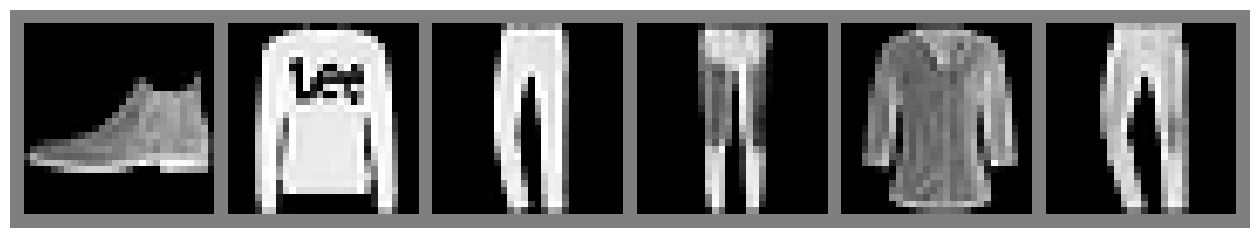

실제 라벨: Ankle Boot  Pullover  Trouser  Trouser  Shirt  Trouser  


In [75]:
# 학습된 모델 평가를 위한 테스트 데이터 시각화 및 라벨 확인

# torchvision 임포트 - 이미지 처리 및 시각화 유틸리티 제공
import torchvision

# 테스트 데이터 로더에서 첫 번째 배치 가져오기
# iter(): DataLoader를 이터레이터로 변환
# next(): Python 내장 함수로 이터레이터에서 첫 번째 배치 추출
# test_loader에는 모델 훈련에 사용되지 않은 10,000개 테스트 샘플이 포함됨
dataiter = iter(test_loader)
images, labels = next(dataiter)

# torchvision.utils.make_grid(): 여러 이미지를 하나의 격자로 결합
# images[:6]: 128개 배치에서 처음 6개 이미지만 선택
# make_grid 결과: 6개 이미지가 가로로 나란히 배치된 하나의 큰 이미지 생성
# - 각 이미지 사이에 패딩(기본 2픽셀) 자동 추가
# - 최종 크기: [3, 32, 182] (높이 32, 너비 182)
grid_image = torchvision.utils.make_grid(images[:6])

# 앞서 정의한 imshow() 함수를 사용하여 격자 이미지 출력
# imshow() 내부 처리:
# 1. 정규화 해제: [-1, 1] → [0, 1] 범위로 복원
# 2. 차원 순서 변경: [C, H, W] → [H, W, C]
# 3. 그레이스케일 처리 및 matplotlib 출력
imshow(grid_image)

# 시각화된 6개 이미지에 해당하는 실제 정답 라벨 출력
print("실제 라벨:", end=" ")
for i in range(6):
    # labels[i].item(): 텐서에서 Python 정수로 변환 (0~9 범위)
    label_idx = labels[i].item()
    
    # labels_map 딕셔너리를 사용하여 숫자를 의류명으로 변환
    # 예: 0 → 'T-Shirt', 1 → 'Trouser' 등
    label_name = labels_map[label_idx]
    
    # 라벨명들을 공백으로 구분하여 가로로 출력
    print(f"{label_name}", end="  ")

print()  # 줄바꿈으로 출력 완료

# 이 시각화의 목적:
# 1. 테스트 데이터의 품질과 다양성 확인
# 2. 모델이 예측해야 할 실제 샘플들 사전 관찰
# 3. 다음 단계에서 모델 예측과 정답 비교 기준 제공

In [76]:
# 학습된 모델을 사용하여 테스트 이미지들의 클래스 예측 수행

# 모델의 순전파 실행: 6개 테스트 이미지에 대한 예측 수행
# images: [6, 1, 28, 28] 형태의 테스트 이미지 배치
# outputs: [6, 10] 형태의 로짓 값들 (각 이미지당 10개 클래스 점수)
with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리 절약 및 속도 향상)
    outputs = net(images[:6])  # 앞서 시각화한 6개 이미지만 예측

# torch.max(): 각 행에서 최대값과 해당 인덱스를 반환
# outputs: [6, 10] 로짓 값들
# dim=1: 두 번째 차원(클래스 차원)에서 최대값 찾기
# 반환값: (최대값들, 최대값의 인덱스들)
# predicted: [6] 형태, 각 이미지의 예측된 클래스 인덱스 (0~9)
_, predicted = torch.max(outputs, 1)

print("모델 예측 결과:", predicted)

# 예측 결과를 의류명으로 변환하여 출력
print("예측된 아이템:", end=" ")
for i in range(6):
    pred_idx = predicted[i].item()  # 텐서를 Python 정수로 변환
    pred_name = labels_map[pred_idx]  # 숫자를 의류명으로 변환
    print(f"{pred_name}", end="  ")
print()

# 실제 정답과 예측 결과 비교
print("\n예측 정확도 분석:")
correct = 0
for i in range(6):
    actual = labels_map[labels[i].item()]
    predicted_item = labels_map[predicted[i].item()]
    is_correct = labels[i].item() == predicted[i].item()
    
    if is_correct:
        correct += 1
    
    print(f"이미지 {i+1}: 실제={actual:12} vs 예측={predicted_item:12} {'✓' if is_correct else '✗'}")

print(f"\n6개 샘플 정확도: {correct}/6 = {correct/6*100:.1f}%")

모델 예측 결과: tensor([9, 2, 1, 1, 6, 1])
예측된 아이템: Ankle Boot  Pullover  Trouser  Trouser  Shirt  Trouser  

예측 정확도 분석:
이미지 1: 실제=Ankle Boot   vs 예측=Ankle Boot   ✓
이미지 2: 실제=Pullover     vs 예측=Pullover     ✓
이미지 3: 실제=Trouser      vs 예측=Trouser      ✓
이미지 4: 실제=Trouser      vs 예측=Trouser      ✓
이미지 5: 실제=Shirt        vs 예측=Shirt        ✓
이미지 6: 실제=Trouser      vs 예측=Trouser      ✓

6개 샘플 정확도: 6/6 = 100.0%
